## Meta-Clustering y Unificación Semántica mediante DBSCAN

**Contexto de la Fase:** Tras superar la validación matemática (Similitud Coseno) de las preguntas generadas por el comité de LLMs, nos enfrentamos a un último desafío de Arquitectura de la Información: la consolidación final. En lugar de seleccionar manualmente una única pregunta ganadora por categoría o forzar una taxonomía rígida, aplicamos una técnica de aprendizaje no supervisado avanzado sobre los *outputs* de los modelos.

Los objetivos de este notebook son: implementar un algoritmo de agrupamiento espacial basado en densidad para encontrar aglomeraciones semánticas naturales entre las preguntas generadas; a diferencia de K-Means, DBSCAN no requiere predefinir el número de clústeres, esto permite que emerjan "Macro-Tópicos" de forma orgánica dictados puramente por la cercanía vectorial; y aprovechar la capacidad nativa de DBSCAN para identificar y etiquetar como "ruido" (Cluster -1) aquellas preguntas generadas por los LLMs que resulten ser alucinaciones aisladas o rarezas léxicas.

### Conexión con Ollama

Siguiendo la misma metodología de conexión a Ollama para acceder a los LLM:

In [ ]:
import requests
import json
import pandas as pd

def consultar_ollama_stream(prompt, modelo_id):
    url = "https://wiig.dia.fi.upm.es/ollama/v1/chat/completions"
    payload = {
        "model": modelo_id,
        "messages": [{"role": "user", "content": prompt}],
        "stream": True
    }
    
    texto_acumulado = ""
    try:
        with requests.post(url, json=payload, stream=True, timeout=1000) as r:
            r.raise_for_status()
            for line in r.iter_lines():
                if not line: continue
                decoded = line.decode("utf-8").replace("data: ", "").strip()
                if decoded == "[DONE]": break
                try:
                    chunk = json.loads(decoded)
                    content = chunk["choices"][0].get("delta", {}).get("content", "")
                    texto_acumulado += content
                except: continue
        return texto_acumulado
    except Exception as e:
        return f"ERROR: {str(e)}"

In [3]:
import requests

def listar_modelos_disponibles():
    url_base = "https://wiig.dia.fi.upm.es/ollama/api/tags"
    try:
        response = requests.get(url_base, timeout=10)
        if response.status_code == 200:
            modelos = [m['name'] for m in response.json().get('models', [])]
            print(f" Modelos disponibles: {modelos}")
            return modelos
        else:
            print(f" No se pudo listar modelos. Status: {response.status_code}")
    except Exception as e:
        print(f" Error de conexión: {e}")
    return []

modelos_reales = listar_modelos_disponibles()

 Modelos disponibles: ['nomic-embed-text-v2-moe:latest', 'deepseek-r1:7b', 'llama3_evaluator:latest', 'gpt-oss:120b', 'deepseek-r1:70b', 'gemma3:27b', 'gemma3:12b', 'gemma3:4b', 'gemma3:1b', 'mistral:7b', 'qwen3:30b', 'qwen3:14b', 'llama3.1:70b', 'llama3.1:8b', 'deepseek-r1:32b', 'nemotron-3-nano:30b', 'deepseek-v3.2:cloud', 'qwen2.5:32b', 'qwen3:1.7b', 'qwen3:8b', 'llama3_easy:latest', 'llama3_hard_Open:latest', 'llama3_easy_Open:latest', 'llama3_hard:latest', 'llama3_medium:latest', 'llama3_medium_Open:latest', 'llama3:latest']


### Vectorización y Proyección en el Espacio Latente
Para que el algoritmo de agrupamiento por densidad (DBSCAN) funcione con la máxima precisión, es imperativo proyectar el conjunto de preguntas generadas en un espacio vectorial altamente sensible a las distancias semánticas absolutas. 

**Decisión de Ingeniería (Modelo de Embeddings):**
Se sustituyen los modelos anteriores por **`nomic-embed-text-v2-moe`**. Esta arquitectura *Mixture of Experts* (MoE) es el Estado del Arte (SOTA) actual en tareas de *Clustering* asimétrico. Para activar el comportamiento óptimo de recuperación semántica del modelo, se implementa la directiva de la arquitectura original, concatenando el prefijo `"search_query: "` a cada oración.

**Metodología de Preparación de Datos:**
Se extraen todas las preguntas válidas generadas por los LLMs (ignorando fallos de servidor o celdas vacías detectadas en fases previas) y se "aplanan" en una lista unidimensional. Se elimina deliberadamente la etiqueta de su "Clúster Original" para no sesgar al modelo. El objetivo es proyectar estas $N$ preguntas en un lienzo en blanco multidimensional y dejar que DBSCAN encuentren las verdaderas agrupaciones de significado.

In [ ]:
import pandas as pd
import numpy as np
import requests
import json


URL_OLLAMA_EMBED = "https://wiig.dia.fi.upm.es/ollama/api/embeddings"
MODELO_NOMIC = "nomic-embed-text-v2-moe:latest"

def obtener_embedding_nomic(texto):
    """Obtiene el vector de embedding usando las best practices de Nomic."""
    prompt_con_prefijo = f"search_query: {texto}"
    
    payload = {
        "model": MODELO_NOMIC,
        "prompt": prompt_con_prefijo
    }
    
    try:
        response = requests.post(URL_OLLAMA_EMBED, json=payload, timeout=60)
        
        if response.status_code == 200:
            return response.json().get('embedding')
        else:
            print(f"Error {response.status_code} en texto '{texto[:30]}...': {response.text}")
            return None
    except Exception as e:
        print(f"Excepción en '{texto[:30]}...': {e}")
        return None


df = pd.read_csv("preguntas_originales_v4_5modelos.csv")

lista_preguntas = []
mapping_indices = []


columnas_modelos = ["qwen3:30b","deepseek-r1:32b","gemma3:27b","gpt-oss:120b","nemotron-3-nano:30b"]
for i, row in df.iterrows():
    for col in columnas_modelos:
        if col in df.columns:
            texto = str(row[col])
            # Limpieza básica para no procesar basura
            if texto and texto not in ["N/A", "ERROR:", "ERROR_SERVIDOR","nan", 'ERROR: 500 Server Error: Internal Server Error for url: https://wiig.dia.fi.upm.es/ollama/v1/chat/completions']:
                lista_preguntas.append(texto)
                mapping_indices.append(i)

# Generar Embeddings
print(f"Generando embeddings para {len(lista_preguntas)} preguntas...")
embeddings = []
for i, q in enumerate(lista_preguntas):
    emb = obtener_embedding_nomic(q)
    if emb is not None:
        embeddings.append(emb)
    if i % 10 == 0:
        print(f"Procesadas {i}/{len(lista_preguntas)} preguntas...")

# Convertir a matriz numpy para DBSCAN
embeddings_final = np.array(embeddings)

print(f"Matriz final generada con forma: {embeddings_final.shape}")

Generando embeddings para 56 preguntas...
Procesadas 0/56 preguntas...
Procesadas 10/56 preguntas...
Procesadas 20/56 preguntas...
Procesadas 30/56 preguntas...
Procesadas 40/56 preguntas...
Procesadas 50/56 preguntas...
Matriz final generada con forma: (56, 768)


### Agrupamiento por Densidad (DBSCAN) y Reducción Dimensional (t-SNE)
Una vez proyectadas todas las preguntas en el espacio latente mediante los *embeddings* SOTA, se procede a la fase de **Meta-Clustering**. El objetivo es descubrir la topología natural de las preguntas generadas, identificando "Macro-Tópicos" y aislando las anomalías semánticas.

**Configuración Algorítmica:**
1. **DBSCAN (Clustering basado en Densidad):** Se configura el algoritmo con un hiperparámetro `min_samples=2` (requiriendo consenso mínimo entre al menos dos modelos de lenguaje) y un radio `eps=0.27`. La métrica de distancia utilizada es el Coseno (`metric='cosine'`). La elección del radio de vecindad (`eps=0.27`) en el algoritmo DBSCAN no es arbitraria, sino el resultado de un proceso iterativo de ajuste heurístico y análisis de sensibilidad espacial. Dado que estamos trabajando en un espacio vectorial semántico continuo de alta dimensionalidad, la densidad de los conceptos médicos fluctúa. Al probar diferentes umbrales, se observaron los siguientes comportamientos algorítmicos: un epsilon alto (>0.3) generaba agrupaciones excesivamente generales (Underfitting Semántico); un epsilon bajo (<20) provocaba un exceso de especificidad y un falso aumento del ruido (Overfitting). DBSCAN fragmentaba conceptos idénticos debido a ligeras variaciones sintácticas en la redacción de los LLMs; y el punto óptimo (según el nivel de especificidad que quería) lograba el equilibrio exacto entre ambos.
2. **t-SNE (Reducción Dimensional):** Para hacer interpretable el resultado espacial, se aplica una transformación t-SNE a 2 dimensiones. Se estabiliza con una inicialización PCA (`init='pca'`) para asegurar la reproducibilidad (`random_state=42`) de la topología proyectada.

**Objetivo del Informe de Unificación:**
El informe resultante mapeará las nuevas densidades descubiertas (Macro-Tópicos) e identificará rigurosamente el "Ruido" (Outliers, identificados nativamente por DBSCAN como `cluster -1`), purgando el dataset definitivo de alucinaciones aisladas.


--- INFORME DE UNIFICACIÓN ---
Preguntas marcadas como RUIDO (Outliers): 17
Macro-tópico 0: Unifica los clusters originales [1]
Macro-tópico 1: Unifica los clusters originales [2]
Macro-tópico 2: Unifica los clusters originales [ 3  4  6  7  8  9 10]
Macro-tópico 3: Unifica los clusters originales [4 6]
Macro-tópico 4: Unifica los clusters originales [7]
Macro-tópico 5: Unifica los clusters originales [ 8 10]
Macro-tópico 6: Unifica los clusters originales [9]
Macro-tópico 7: Unifica los clusters originales [11]


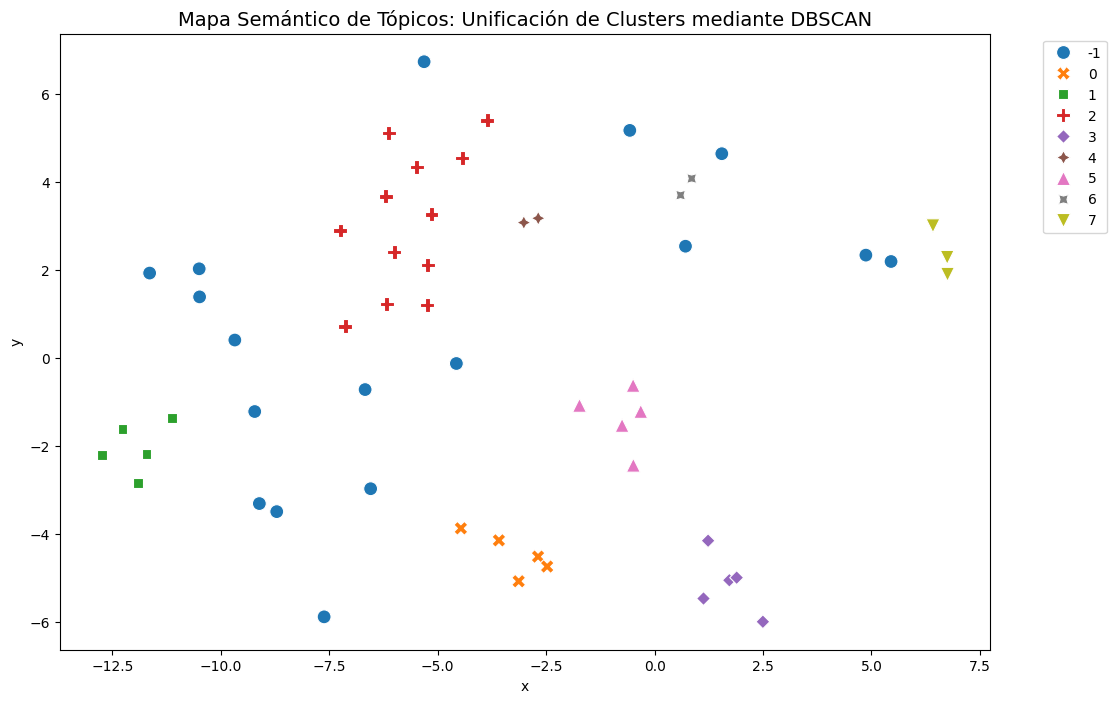

In [ ]:
from sklearn.cluster import DBSCAN
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

dbscan = DBSCAN(eps=0.27, min_samples=2, metric='cosine')
labels = dbscan.fit_predict(embeddings_final)


df_clusters = pd.DataFrame({
    'cluster_original': mapping_indices,
    'pregunta': lista_preguntas,
    'macro_cluster_dbscan': labels
})


fisiones = df_clusters.groupby('macro_cluster_dbscan')['cluster_original'].unique()
print("\n--- INFORME DE UNIFICACIÓN ---")
for macro, originales in fisiones.items():
    if macro == -1:
        print(f"Preguntas marcadas como RUIDO (Outliers): {len(df_clusters[df_clusters.macro_cluster_dbscan == -1])}")
    else:
        print(f"Macro-tópico {macro}: Unifica los clusters originales {originales}")


# Reducimos a 2D
tsne = TSNE(n_components=2, perplexity=15, random_state=42, init='pca', learning_rate='auto')
vis_dims = tsne.fit_transform(embeddings_final)

df_clusters['x'] = vis_dims[:, 0]
df_clusters['y'] = vis_dims[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_clusters, x='x', y='y', 
                hue='macro_cluster_dbscan', 
                style='macro_cluster_dbscan',
                palette='tab10', s=100)


plt.title('Mapa Semántico de Tópicos: Unificación de Clusters mediante DBSCAN', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.savefig('mapa_topicos_dbscan.png', dpi=300)
plt.show()

In [71]:
df_clusters["pregunta"][df_clusters["macro_cluster_dbscan"]==7].to_list()

['¿Cuándo fue la última revisión?',
 '¿Cuál es la fecha de la última revisión de este prospecto?',
 '¿Cuándo se revisó por última vez este prospecto?']